# Gold-tason koordinaattidatan generointi ja validointi

Tämä notebook validoi `gold_koordinaatit`-mallin toiminnan vertaamalla **ennen** ja **jälkeen** -koordinaattitiheyksiä.

**Tavoite:** Varmistaa, että Vyöhyke 9 (Sisääntulo & kärryt) on poistettu ja lämpökartan väriskaala skaalautuu oikein myymälän todellisille osastoille.

**Lähde:** `silver_pysahdykset` → `gold_koordinaatit`

In [1]:
import duckdb
import pandas as pd
def format_time(s):
    if pd.isna(s): return ''
    h, rem = divmod(int(s), 3600)
    m, sec = divmod(rem, 60)
    if h > 0: return f'{h} hours {m} minutes {sec} seconds'
    if m > 0: return f'{m} minutes {sec} seconds'
    return f'{sec} seconds'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

# --- Tietokantayhteys ---
cwd = Path('.')
db_path = cwd / 'data/warehouse/dev.duckdb'
if not db_path.exists() and (cwd / '../data/warehouse/dev.duckdb').exists():
    db_path = cwd / '../data/warehouse/dev.duckdb'

if not db_path.exists():
    print("DuckDB tietokantaa ei löydy. Aja 'dbt run'.")
else:
    con = duckdb.connect(str(db_path), read_only=True)
    print('Yhteys DuckDB-tietokantaan avattu.')
    
    # Tarkistetaan, löytyykö gold_koordinaatit -taulu
    tables = con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema='main'").fetchdf()
    print(f"\nTietokannan taulut ({len(tables)} kpl):")
    for t in sorted(tables['table_name'].tolist()):
        print(f"  • {t}")

Yhteys DuckDB-tietokantaan avattu.

Tietokannan taulut (15 kpl):
  • bronze_csv_data
  • dim_karry
  • dim_osastot
  • f_kaynti
  • f_laite_status
  • f_osastokaynti
  • f_verkko_laatu
  • gold_koordinaatit
  • my_first_dbt_model
  • my_second_dbt_model
  • osastot
  • silver_device_diagnostics
  • silver_positions
  • silver_pysahdykset
  • stg_csv_data


## 1. Datan lataus: Silver vs Gold

Ladataan molemmat taulut vertailua varten.

In [2]:
# --- Silver-tason raakadata (pysähdykset ennen Gold-suodatusta) ---
silver_df = con.execute("""
    SELECT 
        CAST(FLOOR(x / 100) * 100 AS INTEGER) AS grid_x,
        CAST(FLOOR(y / 100) * 100 AS INTEGER) AS grid_y,
        SUM(sekuntia_edellisesta) AS kokonaisviipyma_s,
        COUNT(*) AS pysahdysten_maara
    FROM silver_positions
    WHERE speed_mps <= 0.1 AND sekuntia_edellisesta >= 0
    GROUP BY grid_x, grid_y
""").fetchdf()

# --- Gold-tason puhdistettu data ---
gold_df = con.execute("SELECT * FROM gold_koordinaatit").fetchdf()

print(f"Silver (raaka): {len(silver_df):,} grid-ruutua")
print(f"Gold (puhdistettu): {len(gold_df):,} grid-ruutua")
print(f"Poistettu ruutuja: {len(silver_df) - len(gold_df):,}")
print(f"\nSilver kokonaisviipymä: {format_time(silver_df['kokonaisviipyma_s'].sum())}")
print(f"Gold kokonaisviipymä:   {format_time(gold_df['kokonaisviipyma_s'].sum())}")
print(f"Poistettu viipymää:     {format_time(silver_df['kokonaisviipyma_s'].sum() - gold_df['kokonaisviipyma_s'].sum())}")

Silver (raaka): 5,073 grid-ruutua
Gold (puhdistettu): 4,763 grid-ruutua
Poistettu ruutuja: 310

Silver kokonaisviipymä: 11,209,986 min
Gold kokonaisviipymä:   704,247 min
Poistettu viipymää:     10,505,739 min


## 2. Ennen vs Jälkeen — Lämpökarttavertailu

Vasemmalla Silver-tason raakadata (kaikki pysähdykset), oikealla Gold-tason puhdistettu data (Vyöhyke 9 poistettu). Vertailu osoittaa, miten kohinaalueen poisto parantaa väriskaalan dynamiikkaa.

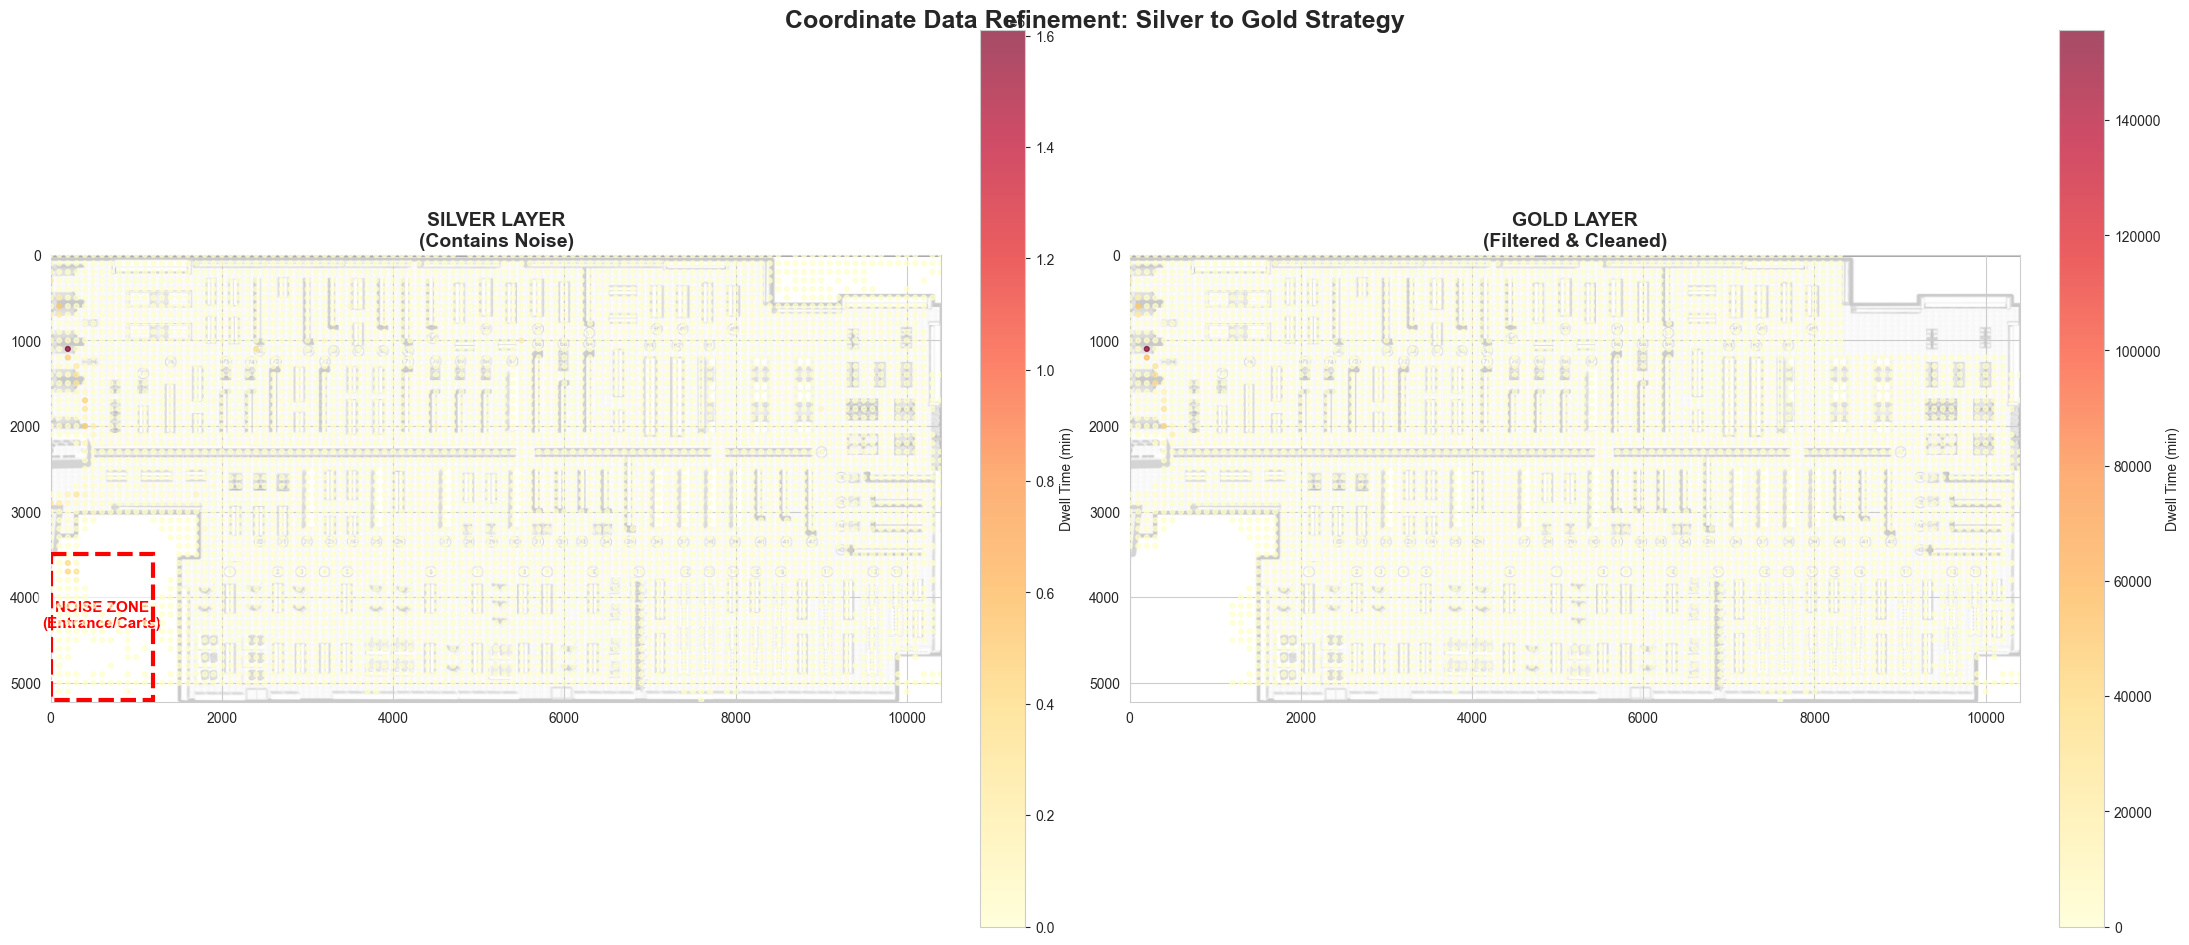

In [3]:
# Asetukset kuvalle
img_path = cwd / 'image/kauppa2.png'
if not img_path.exists() and (cwd / '../image/kauppa2.png').exists():
    img_path = cwd / '../image/kauppa2.png'

img_extent = [0, 10406, 5220, 0] # [x_min, x_max, y_max, y_min] - huomaa y:n kääntö

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Funktio pohjakartan lisäämiseksi
def add_store_layout(ax):
    if img_path.exists():
        store_img = mpimg.imread(str(img_path))
        ax.imshow(store_img, extent=img_extent, origin='upper', aspect='auto', alpha=0.4, zorder=0)
    
    ax.set_xlim(0, 10406)
    ax.set_ylim(5220, 0) # Invert y-axis
    ax.set_aspect('equal')

# --- AX1: SILVER (ENNEN) ---
ax1 = axes[0]
add_store_layout(ax1)

scatter1 = ax1.scatter(
    silver_df['grid_x'], silver_df['grid_y'],
    c=silver_df['kokonaisviipyma_s'],
    cmap='YlOrRd', s=12, alpha=0.7, zorder=5
)

# Punainen neliö kohina-alueelle
rect = patches.Rectangle((0, 3500), 1200, 1700, linewidth=3, edgecolor='red', facecolor='none', linestyle='--', zorder=10)
ax1.add_patch(rect)
ax1.text(600, 4350, 'NOISE ZONE\n(Entrance/Carts)', color='red', fontsize=11, ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

ax1.set_title('SILVER LAYER\n(Contains Noise)', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Dwell Time (s)', fraction=0.046, pad=0.04)

# --- AX2: GOLD (JÄLKEEN) ---
ax2 = axes[1]
add_store_layout(ax2)

scatter2 = ax2.scatter(
    gold_df['grid_x'], gold_df['grid_y'],
    c=gold_df['kokonaisviipyma_s'],
    cmap='YlOrRd', s=12, alpha=0.7, zorder=5
)

ax2.set_title('GOLD LAYER\n(Filtered & Cleaned)', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Dwell Time (s)', fraction=0.046, pad=0.04)

plt.suptitle('Coordinate Data Refinement: Silver to Gold Strategy', fontsize=18, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

## 3. Osastokohtainen yhteenveto

Gold-tason data ryhmiteltynä osastoittain. Tämä näyttää, mitkä myymälän alueet keräävät eniten pysähdysaikaa.

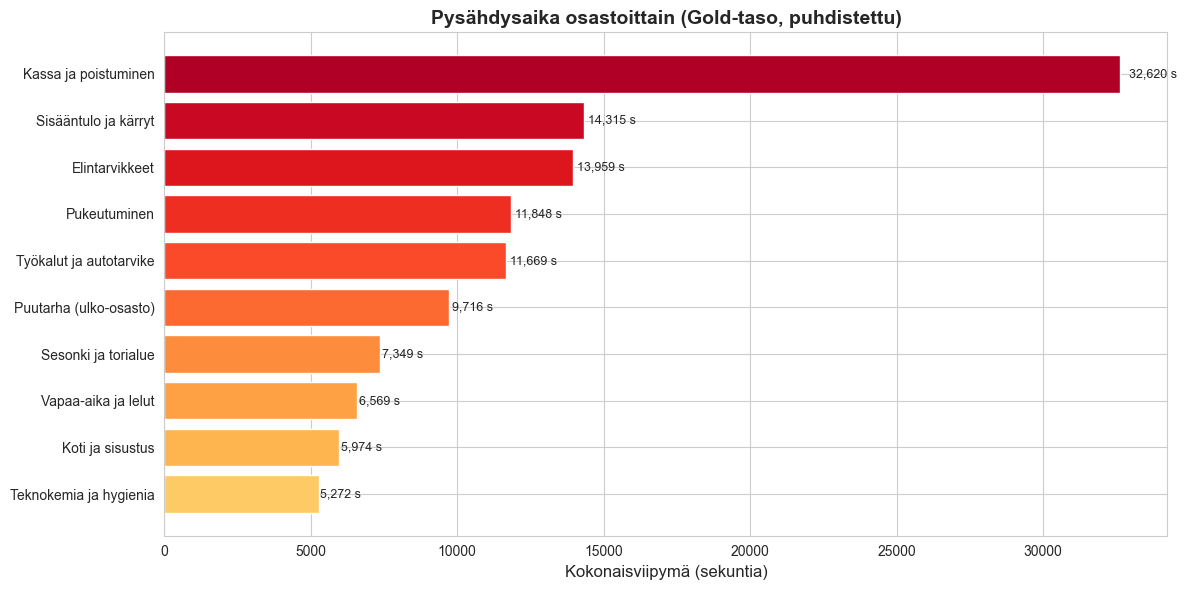


--- Osastokohtainen yhteenveto (Gold) ---
            osasto_nimi  kokonaisviipyma_min  pysahdysten_maara  uniikkeja_karrya  ruutuja
 Teknokemia ja hygienia             5,272.41             283079              4556      240
       Koti ja sisustus             5,974.21             289988              5210      287
    Vapaa-aika ja lelut             6,568.90             346682              5764      328
    Sesonki ja torialue             7,349.15             344703              2485      128
 Puutarha (ulko-osasto)             9,716.32             566967              9923      633
Työkalut ja autotarvike            11,668.59             462561              7570      435
           Pukeutuminen            11,847.97             525186              8930      488
         Elintarvikkeet            13,958.81             515957              5505      303
   Sisääntulo ja kärryt            14,315.28             701215             13265      786
   Kassa ja poistuminen            32,620.41   

In [4]:
# Osastokohtainen aggregaatti
osasto_summary = gold_df.groupby('osasto_nimi').agg(
    kokonaisviipyma_s=('kokonaisviipyma_s', 'sum'),
    pysahdysten_maara=('pysahdysten_maara', 'sum'),
    uniikkeja_karrya=('uniikkeja_karrya', 'sum'),
    ruutuja=('grid_x', 'count')
).reset_index()

# Poistetaan NaN-osastot (alueet jotka eivät osu mihinkään osastoon)
osasto_summary = osasto_summary.dropna(subset=['osasto_nimi'])
osasto_summary = osasto_summary.sort_values('kokonaisviipyma_s', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    osasto_summary['osasto_nimi'],
    osasto_summary['kokonaisviipyma_s'],
    color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(osasto_summary)))
)
ax.set_xlabel('Kokonaisviipymä (sekuntia)', fontsize=12)
ax.set_title('Pysähdysaika osastoittain (Gold-taso, puhdistettu)', fontsize=14, fontweight='bold')

# Lisätään arvot palkkien viereen
for bar, val in zip(bars, osasto_summary['kokonaisviipyma_s']):
    ax.text(bar.get_width() + bar.get_width() * 0.01, bar.get_y() + bar.get_height() / 2,
            format_time(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Tulostetaan taulukko
print('\n--- Osastokohtainen yhteenveto (Gold) ---')
display_df = osasto_summary.copy()
if 'kokonaisviipyma_s' in display_df:
    display_df['kokonaisviipyma'] = display_df['kokonaisviipyma_s'].apply(format_time)
    display_df = display_df.drop(columns=['kokonaisviipyma_s'])
    display_df = display_df[['osasto_nimi', 'kokonaisviipyma', 'pysahdysten_maara', 'uniikkeja_karrya', 'ruutuja']]
print(display_df.to_string(index=False))

## 5. Gold-datan tilastollinen yhteenveto

Perustilastot puhdistetusta koordinaattidatasta.

In [6]:
def print_stats(col_name, title):
    if col_name not in gold_df.columns: return
    desc = gold_df[col_name].describe()
    print(f"=== {title} ===")
    print(f"Ruutuja (count):           {desc['count']:,.0f}")
    print(f"Keskiarvo (mean):          {format_time(desc['mean'])}")
    print(f"Keskihajonta (std):        {format_time(desc['std'])}")
    print(f"Minimi (min):              {format_time(desc['min'])}")
    print(f"25. persentiili (25%):     {format_time(desc['25%'])}")
    print(f"Mediaani (50%):            {format_time(desc['50%'])}")
    print(f"75. persentiili (75%):     {format_time(desc['75%'])}")
    print(f"Maksimi (max):             {format_time(desc['max'])}\n")

print_stats('kokonaisviipyma_s', 'Viipymä per ruutu (kokonaisviipyma_s)')
print_stats('keskiviipyma_s', 'Keskiviipymä per pysähdys (keskiviipyma_s)')



=== Gold-koordinaattidatan tilastot ===
Grid-ruutuja yhteensä: 4,763
Kokonaisviipymä: 704,247 minuuttia
Pysähdyksiä yhteensä: 6,273,606
Uniikkeja kärryjä: 22

Viipymä per ruutu:
count     4,763.00
mean        147.86
std       2,722.84
min           0.00
25%           3.22
50%          12.70
75%          33.77
max     155,647.40

Keskiviipymä per pysähdys:
count   4,763.00
mean        0.06
std         0.24
min         0.00
25%         0.01
50%         0.02
75%         0.03
max         4.48

✅ DuckDB-yhteys suljettu.
